In [8]:
import matplotlib.pyplot as plt
import math

class LSystem2D:
    def __init__(self, axiom, width, length, angle):
        self.axiom = axiom
        self.state = axiom
        self.width = width
        self.length = length
        self.angle = angle
        self.rules = {}

    def add_rules(self, *rules):
        for key, value in rules:
            self.rules[key] = value

    def generate_path(self, n_iter):
        self.state = self.axiom
        for _ in range(n_iter):
            new_state = ""
            for char in self.state:
                new_state += self.rules.get(char, char)
            self.state = new_state

    def draw_turtle(self, start_pos=(0, 0), start_angle=0):
        x, y = start_pos
        current_angle = start_angle
        stack = []

        lines_x = []
        lines_y = []

        for move in self.state:
            if move in ('F', 'G'):
                new_x = x + self.length * math.cos(math.radians(current_angle))
                new_y = y + self.length * math.sin(math.radians(current_angle))

                lines_x.extend([x, new_x, None])
                lines_y.extend([y, new_y, None])

                x, y = new_x, new_y

            elif move == 'S':
                x = x + self.length * math.cos(math.radians(current_angle))
                y = y + self.length * math.sin(math.radians(current_angle))

            elif move == '+':
                current_angle += self.angle

            elif move == '-':
                current_angle -= self.angle

            elif move == '[':
                stack.append((x, y, current_angle))

            elif move == ']':
                x, y, current_angle = stack.pop()

        plt.figure(figsize=(10, 10))
        plt.plot(lines_x, lines_y, linewidth=self.width, color='teal')
        plt.axis("equal")
        plt.axis("off")
        plt.show()

Hilbert Curve

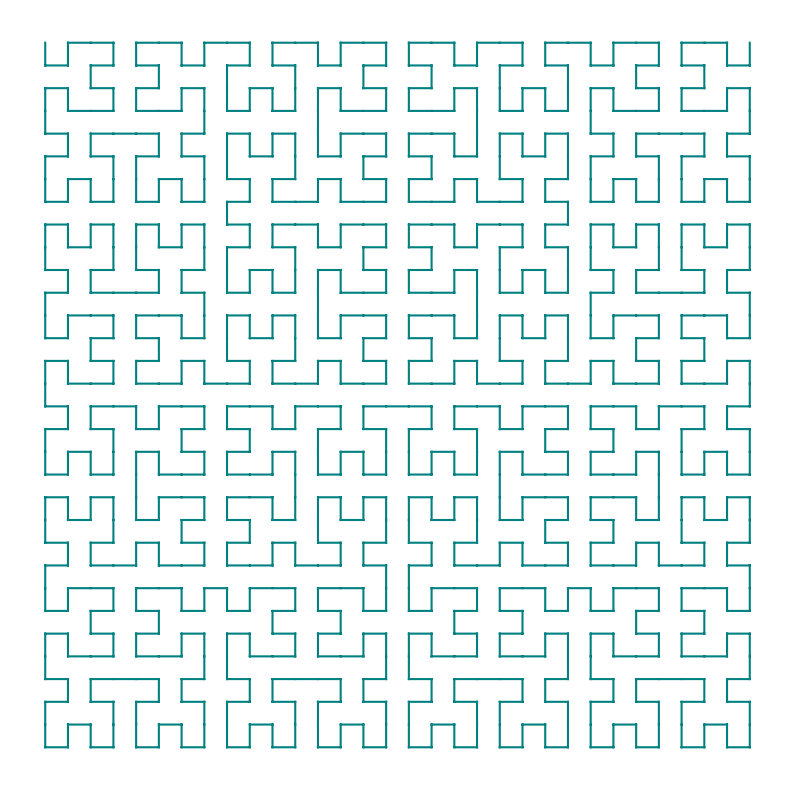

In [7]:
pen_width = 1.5
f_len = 5
angle = 90
axiom = "X"

l_sys_1 = LSystem2D(axiom, pen_width, f_len, angle)
l_sys_1.add_rules(
    ("X", "-YF+XFX+FY-"),
    ("Y", "+XF-YFY-FX+")
)

l_sys_1.generate_path(5)
l_sys_1.draw_turtle((0, 0), 0)

Minkowski Island

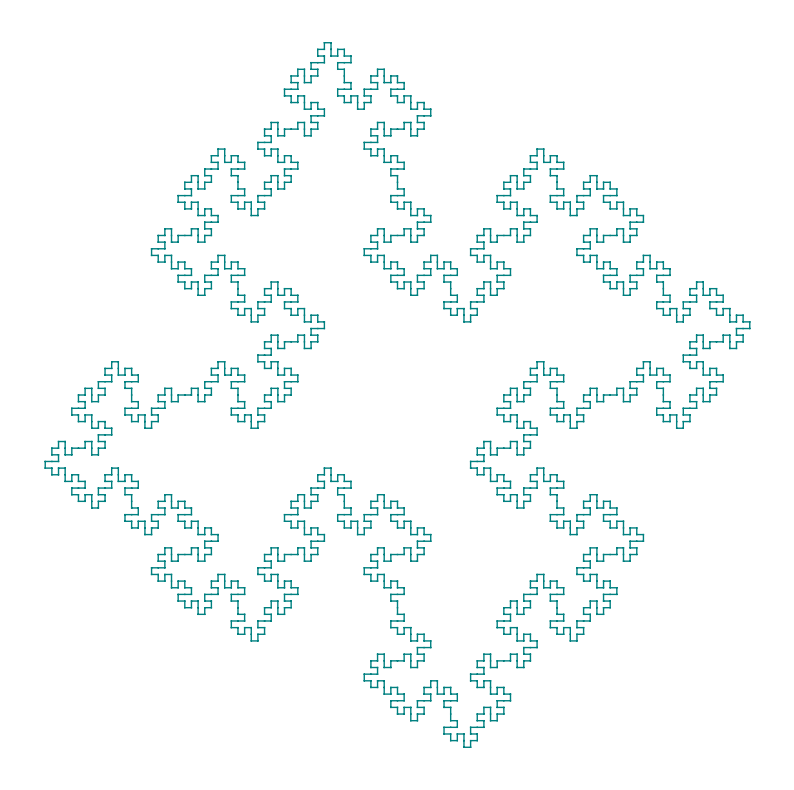

In [6]:
pen_width = 1
f_len = 4
angle = 90
axiom = "F+F+F+F"

l_sys_2 = LSystem2D(axiom, pen_width, f_len, angle)
l_sys_2.add_rules(
    ("F", "F+F-F-FF+F+F-F")
)

l_sys_2.generate_path(3)
l_sys_2.draw_turtle((0, 0), 0)

Advanced Plant

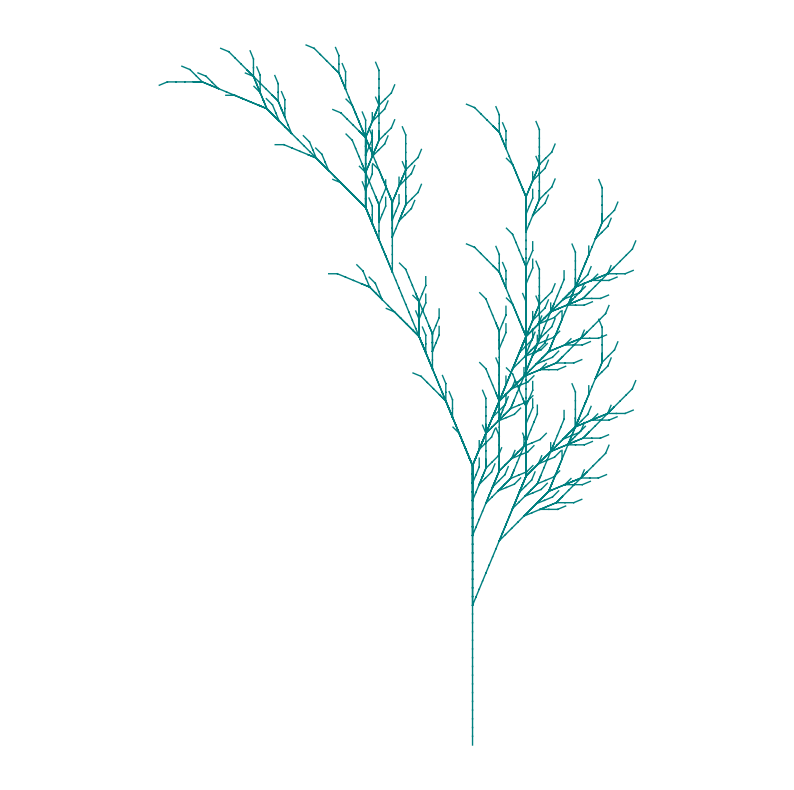

In [5]:
pen_width = 1
f_len = 3
angle = 22.5
axiom = "X"

l_sys_3 = LSystem2D(axiom, pen_width, f_len, angle)
l_sys_3.add_rules(
    ("X", "F-[[X]+X]+F[+FX]-X"),
    ("F", "FF")
)

l_sys_3.generate_path(5)
l_sys_3.draw_turtle((0, 0), 90)